In [1]:
import pandas as pd
import numpy as np
from uncertainties import unumpy as unp
from scipy.stats import ks_2samp, mannwhitneyu, anderson_ksamp, pearsonr
import statsmodels.api as sm

import matplotlib as mpl
from matplotlib import pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import LogLocator, ScalarFormatter, LogFormatter
import seaborn as sns

palette = 'viridis'
font = {'color':  'black', 'weight': 'normal','size': 14}
font_cb = {'color':  'black', 'weight': 'normal','size': 12}
labelsize=12

import warnings
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv('Dados\data.csv', index_col='Cluster')
df = pd.read_csv(r'Dados\results.csv', index_col='Cluster')

In [211]:
def calcula_fracoes(data, mask_mass, mask_comp_mass,):
    
    N_stars = mask_mass.sum() + mask_comp_mass.sum()
    N_prim = ((mask_mass) & (data['q'] > 0)).sum()
    F_prim = N_prim / N_stars
    
    N_comp = (mask_comp_mass & (data['q'] > 0)).sum()
    F_comp = N_comp / N_stars 
    
    
    N_BS = N_prim + N_comp
    F_BS = N_BS / N_stars

    return F_prim, F_comp, F_BS, N_prim, N_comp, N_BS


def bootstrap_samples(data, n_boot=1000, random_state=None):
    aux=data.copy(deep=True)
    aux.index = np
    rng = np.random.default_rng(random_state)
    idx = np.arange(len(aux))
    samples_bootstrap = []
    for _ in range(n_boot):
        resample_idx = rng.choice(idx, size=len(idx), replace=True)
        sample = aux.iloc[resample_idx].copy()

        #Redefine as massas com base nas incertezas de mass e comp_mass
        #low_mass = 10**sample['mass']-sample['er_mass']
        #low_comp_mass = 10**sample['comp_mass']-sample['er_comp_mass']
        #low_comp_mass = np.where(low_comp_mass<0, 0, low_comp_mass)

        #high_mass = 10**sample['mass']+sample['er_mass']
        #high_comp_mass = 10**sample['comp_mass']+sample['er_comp_mass']

        #new_masses = rng.uniform(low_mass, high_mass)
        #new_comp_masses = rng.uniform(low_comp_mass, high_comp_mass)

        #new_qs = new_comp_masses / np.clip(new_masses, 1e-12, None)
        #new_qs = np.where(new_qs>1, 1, new_qs)
        
        #sample['mass'] = np.log10(new_masses)
        #sample['comp_mass'] = np.log10(new_comp_masses)
        #sample['q'] = new_qs
        
        samples_bootstrap.append(sample[['mass','comp_mass','q']])
        
    return samples_bootstrap


def realiza_loop(aux, min_mass, max_mass, dm=0.05):
        
        m_min = min_mass
        m_max = m_min+dm
        
        mass_bins = []
        F_prim_arr = []
        F_comp_arr = []
        F_BS_arr = []
        
        F_prim_p16, F_prim_p84 = [], []
        F_comp_p16, F_comp_p84 = [], []
        F_BS_p16,   F_BS_p84   = [], []
        
            
        
        while m_min <= max_mass:
            
            if m_max> max_mass:
                break
                
            if m_min < np.log10(4):
                dm = 0.05
            else:
                dm = np.log10(1 + 1 / (10**m_min))
                
            mask_mass = (aux['log_mass'] >=m_min) & (aux['log_mass'] <m_max)
            mask_comp_mass = (aux['log_comp_mass'] >=m_min) & (aux['log_comp_mass'] < m_max)
            total_stars = mask_mass.sum() + mask_comp_mass.sum()
            
            if total_stars>=100:
                F_prim, F_comp, F_BS, N_prim, N_comp, N_BS = calcula_fracoes(aux, mask_mass, mask_comp_mass)
                
                masses = np.concatenate([aux[mask_mass]['log_mass'].to_numpy(), aux[mask_comp_mass]['log_comp_mass'].to_numpy()])             
                median_mass = np.median(masses)
                mass_bins.append(median_mass) 
                F_prim_arr.append(F_prim) 
                F_comp_arr.append(F_comp) 
                F_BS_arr.append(F_BS)

                m_min = m_min + dm 
            m_max = m_max + dm

        return (np.array(mass_bins),np.array(F_prim_arr),np.array(F_comp_arr),np.array(F_BS_arr))

    

In [170]:
results =[]
qs = []
p16 = []
p84 = []

aux = data[['mass', 'er_mass', 'comp_mass', 'er_comp_mass','q']].copy(deep=True)
aux['log_mass'] = np.log10(aux['mass'])
aux['log_comp_mass'] = np.log10(aux['comp_mass'])
min_mass = min(aux['log_mass'].min(), aux[aux['log_comp_mass']>0]['log_comp_mass'].min())
max_mass = aux['log_mass'].max()

mass_bins, F_prim_arr, F_comp_arr, F_BS_arr, qs = realiza_loop(aux[['mass', 'comp_mass','log_mass', 'log_comp_mass', 'q']],min_mass, max_mass, dm=0.05)

results.append(mass_bins) 
results.append(F_prim_arr) 
results.append(F_comp_arr) 
results.append(F_BS_arr) 

boot_samples = bootstrap_samples(aux, n_boot=1000, random_state=1)

Fp_boot, Fc_boot, Fbs_boot, qs_boot = [], [], [], []

for boot_sample in boot_samples:
    
    min_mass = min(boot_sample['mass'].min(), boot_sample[boot_sample['comp_mass']>0]['comp_mass'].min())
    max_mass = boot_sample['mass'].max()
        
    mb, Fp, Fc, Fbs, qsb = realiza_loop(boot_sample,min_mass, max_mass, dm=0.05)

    Fp_i  = np.interp(mass_bins, mb, Fp, left=np.nan, right=np.nan)
    Fc_i  = np.interp(mass_bins, mb, Fc, left=np.nan, right=np.nan)
    Fbs_i = np.interp(mass_bins, mb, Fbs, left=np.nan, right=np.nan)
    qs_i = np.interp(mass_bins, mb, qsb, left=np.nan, right=np.nan)
    
    Fp_boot.append(Fp_i)
    Fc_boot.append(Fc_i)
    Fbs_boot.append(Fbs_i)
    qs_boot.append(qs_i)

Fp_boot = np.array(Fp_boot)
Fc_boot = np.array(Fc_boot)
Fbs_boot = np.array(Fbs_boot)
#qs_boot_min = [min(valores) for valores in zip()]

Fp_p16 = np.nanpercentile(Fp_boot, 16, axis=0)
Fp_p50 = np.nanpercentile(Fp_boot, 50, axis=0)
Fp_p84 = np.nanpercentile(Fp_boot, 84, axis=0)

Fc_p16 = np.nanpercentile(Fc_boot, 16, axis=0)
Fc_p50 = np.nanpercentile(Fc_boot, 50, axis=0)
Fc_p84 = np.nanpercentile(Fc_boot, 84, axis=0)

Fbs_p16 = np.nanpercentile(Fbs_boot, 16, axis=0)
Fbs_p50 = np.nanpercentile(Fbs_boot, 50, axis=0)
Fbs_p84 = np.nanpercentile(Fbs_boot, 84, axis=0)

qs_p16 = np.nanpercentile(qs_boot, 16, axis=0)
qs_p50 = np.nanpercentile(qs_boot, 50, axis=0)
qs_p84 = np.nanpercentile(qs_boot, 84, axis=0)

p16.append(Fp_p16)
p16.append(Fc_p16)
p16.append(Fbs_p16)
p16.append(qs_p16)
    
p84.append(Fp_p84)
p84.append(Fc_p84)
p84.append(Fbs_p84)
p84.append(qs_p84)


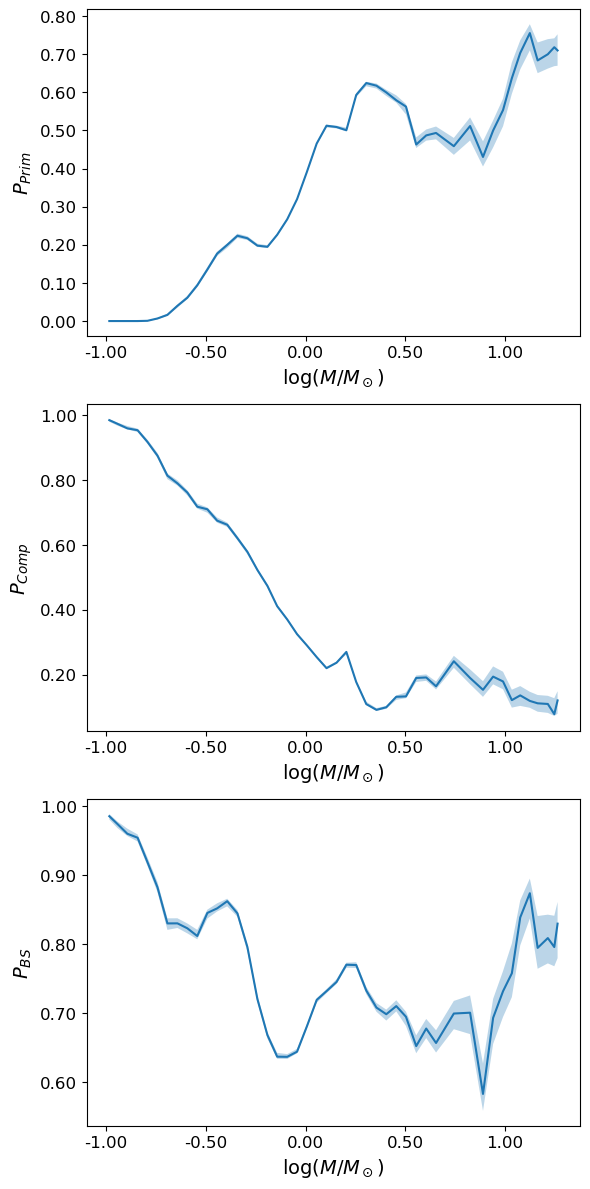

In [173]:
fig, axs = plt.subplots(3,1, figsize=(6,12))


for i in range(1, len(results)):
    j =i-1
   
    axs[j].plot(results[0],  results[i],)
    axs[j].fill_between(results[0], p16[j], p84[j], alpha=0.3)
                    

axs[0].set_ylabel(r'$P_{Prim}$', fontdict=font)
axs[1].set_ylabel(r'$P_{Comp}$', fontdict=font)
axs[2].set_ylabel(r'$P_{BS}$', fontdict=font)
for ax in axs:
    ax.set_xlabel(r'$\log(M/M_\odot)$', fontdict=font)
    ax.tick_params(labelleft=True, labelbottom=True, labelsize=labelsize)
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
plt.tight_layout()
plt.savefig('Figures/dist_fb_por_massa.png', dpi=300)
plt.show() 

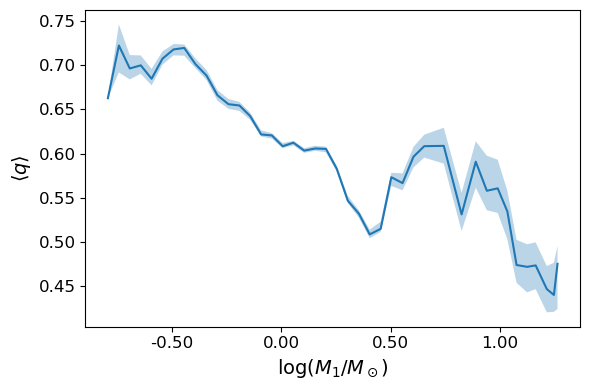

In [184]:
fig, axs = plt.subplots(figsize=(6,4))


   
axs.plot(results[0],  qs,)
axs.fill_between(results[0], p16[-1], p84[-1], alpha=0.3)
                    


axs.set_ylabel(r'$\langle q \rangle$', fontdict=font)
axs.set_xlabel(r'$\log(M_1/M_\odot)$', fontdict=font)
axs.tick_params(labelleft=True, labelbottom=True, labelsize=labelsize)
axs.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
axs.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
plt.tight_layout()
plt.savefig('Figures/dist_q_por_massa.png', dpi=300)
plt.show() 

In [212]:
def bootstrap_samples(data, n_boot=1000, random_state=None):
    rng = np.random.default_rng(random_state)
    samples_bootstrap = []
    for _ in range(n_boot):
        sample = data.copy()

        #Redefine as massas com base nas incertezas de mass e comp_mass
        mass = sample['mass']
        dm = sample['er_mass']
        comp_mass = sample['comp_mass']
        dcm = sample['er_comp_mass']

        new_masses = np.random.uniform(mass-dm, mass+dm)
        
        
        new_comp_masses = np.random.uniform(comp_mass-dcm, comp_mass+dcm)
        new_comp_masses = np.clip(new_comp_masses, 0, new_masses)
        

        new_qs = new_comp_masses / new_masses
        
        sample['log_mass'] = np.log10(new_masses)
        sample['log_comp_mass'] = np.log10(new_comp_masses)
        sample['q'] = new_qs
        
        samples_bootstrap.append(sample[['mass','comp_mass','log_mass','log_comp_mass','q']])
        
    return samples_bootstrap

In [213]:
aux = data[['mass', 'er_mass', 'comp_mass', 'er_comp_mass','q']].copy(deep=True)
aux['log_mass'] = np.log10(aux['mass'])
aux['log_comp_mass'] = np.log10(aux['comp_mass'])
min_mass = min(aux['log_mass'].min(), aux[aux['log_comp_mass']>0]['log_comp_mass'].min())
max_mass = aux['log_mass'].max()

mass_bins, F_prim_arr, F_comp_arr, F_BS_arr = realiza_loop(aux[['mass', 'comp_mass','log_mass', 'log_comp_mass', 'q']],min_mass, max_mass, dm=0.05)

In [216]:
mass_bins, qs = realiza_loop_q(aux[aux['q']>0][['log_mass', 'q']],aux.log_mass.min(), aux.log_mass.max(), dm=0.05)

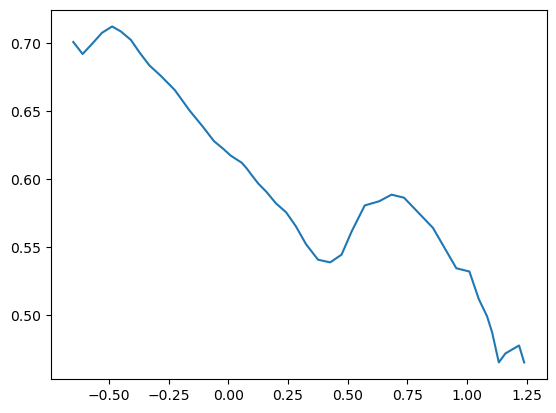

In [217]:
plt.plot(mass_bins,  qs,)

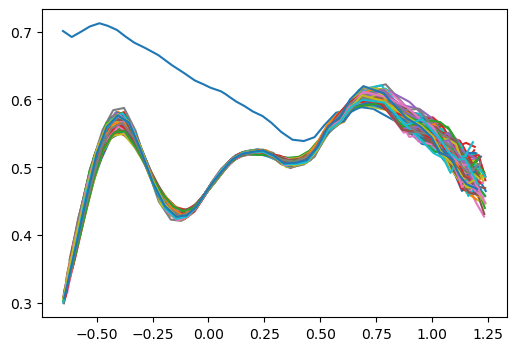

In [413]:
fig, axs = plt.subplots(figsize=(6,4))   
axs.plot(mass_bins,  qs,)
boot_samples = bootstrap_samples(aux, n_boot=100, random_state=1)
results =[]
p16 = []
p84 = []
Fp_boot, Fc_boot, Fbs_boot, qs_boot = [], [], [], []

for boot_sample in boot_samples:
    
    min_mass = min(boot_sample['log_mass'].min(), boot_sample[boot_sample['log_comp_mass']>0]['log_comp_mass'].min())
    max_mass = boot_sample['log_mass'].max()
    binarias = boot_sample[boot_sample['q']>0]
    mb, qsb = realiza_loop_q(binarias[['log_mass', 'q']],binarias.log_mass.min(), binarias.log_mass.max(), dm=0.05)
    mask = (mb >= mass_bins.min()) & (mb <= mass_bins.max())
    qsb = np.array(qsb)
    qsb = qsb[mask]
    mb = mb[mask]

    qs_i = np.interp(mass_bins, mb, qsb, left=np.nan, right=np.nan)
    qs_boot.append(qs_i)
    axs.plot(mb, qsb)

In [405]:
len(mass_bins)

44

In [406]:
len(mb)

45

In [359]:
mask = (mb >= mass_bins.min()) & (mb <= mass_bins.max())
qsb = np.array(qsb)
qsb = qsb[mask]
mb = mb[mask]


In [360]:
len(qsb)

45

In [215]:
def realiza_loop_q(aux, min_mass, max_mass, dm=0.05):
        
        m_min = min_mass
        m_max = m_min+dm
        
        mass_bins = []
        qs_arr = []      
            
        while m_min <= max_mass:
            
            if m_max> max_mass:
                break
                
            if m_min < np.log10(4):
                dm = 0.05
            else:
                dm = np.log10(1 + 1 / (10**m_min))
                
            mask_mass = (aux['log_mass'] >=m_min) & (aux['log_mass'] <m_max)
            total_stars = mask_mass.sum()
            
            if total_stars>=100:                 
                median_mass = np.median(aux[mask_mass]['log_mass'].median())
                mass_bins.append(median_mass)
                qs_arr.append(aux[mask_mass]['q'].mean())      
                m_min = m_min + dm 
            m_max = m_max + dm

        return (np.array(mass_bins), np.array(qs_arr))

    

In [364]:
qs_i = np.interp(mass_bins, mb, qsb, left=np.nan, right=np.nan)

In [ ]:
mass = data.mass.values
dm = data.er_mass.values

comp_mass = data.comp_mass.values
dcm = data.er_comp_mass.values


mass

In [16]:
mass = data.mass.values
dm = data.er_mass.values

comp_mass = data.comp_mass.values
dcm = data.er_comp_mass.values

rng = np.random.default_rng(1)
m1 = []
m2 =[]
for _ in range(0,10):
    new_mass = rng.uniform(mass-dm, mass+dm)

    new_comp_mass = rng.uniform(comp_mass-dcm, comp_mass+dcm)
    new_comp_mass = np.clip(new_comp_mass, 0,  np.minimum(new_mass, comp_mass + dcm))
    m1.append(new_mass)
    m2.append(new_comp_mass)

In [347]:
#Bootstrap nas massas estelares com base nas incertezas

#Cria arrays com as massas e as incertezas das binárias
#===================================================
mass = data[data['q']>0].mass.values
Dm = data[data['q']>0].er_mass.values
comp_mass = data[data['q']>0].comp_mass.values
Dcm = data[data['q']>0].er_comp_mass.values
#===================================================


n_boots = 1000
random_state = 1
rng = np.random.default_rng(random_state)
log_dm = 0.05

#Loop para gerar as reamostragens
qs_boot = []
for _ in range(0,n_boots):
    #Considerando uma distibuição uniforme para as novas massas
    
    mass_boot = rng.uniform(mass-Dm, mass+Dm)
    mass_validation = (mass_boot<0) | (mass_boot< mass-Dm) | (mass_boot>mass+Dm)
    while len(mass_boot[mass_validation])>0:
        mass_boot[mass_validation] = rng.uniform(mass[mass_validation]-Dm[mass_validation], 
                                                 mass[mass_validation]+Dm[mass_validation])
        mass_validation = (mass_boot<0) | (mass_boot< mass-Dm) | (mass_boot>mass+Dm)
        
    comp_mass_boot = rng.uniform(comp_mass-Dcm, comp_mass+Dcm)
    
    comp_mass_validation = (comp_mass_boot<0) | (comp_mass_boot>mass_boot) 
    j=0
    while len(comp_mass_boot[comp_mass_validation])>0:
        if j>100:
            comp_mass_boot[comp_mass_validation] = np.minimum(comp_mass[comp_mass_validation], mass_boot[comp_mass_validation])
            break
        comp_mass_boot[comp_mass_validation] = rng.uniform(comp_mass[comp_mass_validation]-Dcm[comp_mass_validation], 
                                                     comp_mass[comp_mass_validation]+Dcm[comp_mass_validation])
        comp_mass_validation = (comp_mass_boot < 0) | (comp_mass_boot > mass_boot)
        j+=1   
    
    q_boot = (comp_mass_boot/mass_boot)
    mask_binarias = q_boot >0
    q_boot = q_boot[mask_binarias]
    mass_boot = mass_boot[mask_binarias]
    comp_mass_boot = comp_mass_boot[mask_binarias]
    
    #======================================================================

    m1 = np.log10(mass_boot)
    
    idx = np.argsort(m1)
    m1 = m1[idx]
    q_boot = q_boot[idx]
    
    mb = []
    qs_arr = []
    
    m_min = m1.min()
    m_max = m_min +log_dm
    max_mass = m1.max()
    
    while m_min <= max_mass:
        # recalcular dm
        if m_max > max_mass:
            break
        if m_min < np.log10(4):
            log_dm = 0.05
        else:
            log_dm = np.log10(1 + 1 / (10**m_min))
        
        
        # máscara do bin
        mask_mass = (m1 >= m_min) & (m1 < m_max)
        total_stars = mask_mass.sum()
        
        if total_stars >= 100:
            mb.append(np.median(m1[mask_mass]))
            qs_arr.append(q_boot[mask_mass].mean())
            m_min = m_min+log_dm  
        m_max = m_max + log_dm

    qs_i = np.interp(mass_bins, mb, qs_arr, left=np.nan, right=np.nan)
    qs_boot.append(qs_i)


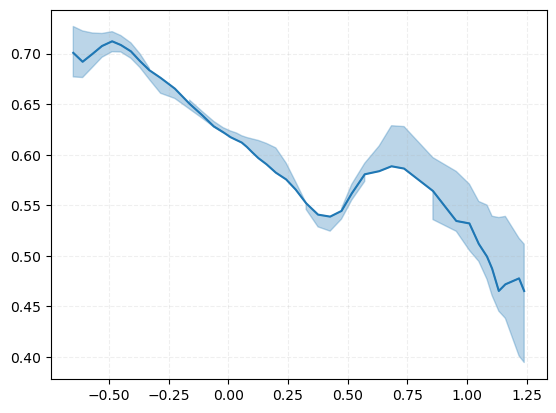

In [349]:
minimos = [min(col) for col in zip(*qs_boot)]
maximos = [max(col) for col in zip(*qs_boot)]
plt.fill_between(mass_bins, qs, maximos, alpha=0.3, color='tab:blue', where = maximos>=qs)
plt.fill_between(mass_bins, minimos, qs, alpha=0.3, color='tab:blue', where = minimos<=qs)


plt.plot(mass_bins, qs)

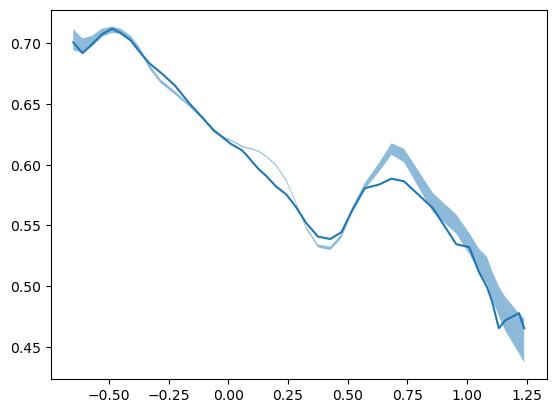

In [336]:
#Bootstrap nas massas estelares com base nas incertezas

#Cria arrays com as massas e as incertezas das binárias
#===================================================
mass = data[data['q']>0].mass.values
Dm = data[data['q']>0].er_mass.values
comp_mass = data[data['q']>0].comp_mass.values
Dcm = data[data['q']>0].er_comp_mass.values
#===================================================


n_boots = 1000
random_state = 1
rng = np.random.default_rng(random_state)
log_dm = 0.05

#Loop para gerar as reamostragens
qs_boot = []
for _ in range(0,n_boots):
    
    #Considerando uma distribuição gaussiana para as novas massas
    mass_boot = rng.normal(mass, Dm)
    mass_validation = (mass_boot<0) | (mass_boot< mass-Dm) | (mass_boot>mass+Dm)
    j=0
    while len(mass_boot[mass_validation])>0:
        if j >100:
            mass_boot[mass_validation] = mass[mass_validation]
            break
        mass_boot[mass_validation] = rng.normal(mass[mass_validation], Dm[mass_validation])
        mass_validation = (mass_boot<0) | (mass_boot< mass-Dm) | (mass_boot>mass+Dm)
        j+=1
    comp_mass_boot = rng.normal(comp_mass, Dcm)
    comp_mass_validation = (comp_mass_boot<0) | (comp_mass_boot>mass_boot) | (comp_mass_boot<comp_mass - Dcm) | (comp_mass_boot>comp_mass + Dcm)
    j=0
    while len(comp_mass_boot[comp_mass_validation])>0:
        if j >100:
            comp_mass_boot[comp_mass_validation] = comp_mass[comp_mass_validation]
            break        
        comp_mass_boot[comp_mass_validation] = rng.normal(comp_mass[comp_mass_validation], Dcm[comp_mass_validation])
        comp_mass_validation = (comp_mass_boot<0) | (comp_mass_boot>mass_boot) | (comp_mass_boot<comp_mass - Dcm) | (comp_mass_boot>comp_mass + Dcm)
        j+=1
    
    q_boot = (comp_mass_boot/mass_boot)
    mask_binarias = q_boot >0
    q_boot = q_boot[mask_binarias]
    mass_boot = mass_boot[mask_binarias]
    comp_mass_boot = comp_mass_boot[mask_binarias]
    
    #======================================================================

    m1 = np.log10(mass_boot)
    
    idx = np.argsort(m1)
    m1 = m1[idx]
    q_boot = q_boot[idx]
    
    mb = []
    qs_arr = []
    
    m_min = m1.min()
    m_max = m_min +log_dm
    max_mass = m1.max()
    
    while m_min <= max_mass:
        # recalcular dm
        if m_max > max_mass:
            break
        if m_min < np.log10(4):
            log_dm = 0.05
        else:
            log_dm = np.log10(1 + 1 / (10**m_min))
        
        
        # máscara do bin
        mask_mass = (m1 >= m_min) & (m1 < m_max)
        total_stars = mask_mass.sum()
        
        if total_stars >= 100:
            mb.append(np.median(m1[mask_mass]))
            qs_arr.append(q_boot[mask_mass].mean())
            m_min = m_min+log_dm  
        m_max = m_max + log_dm

    qs_i = np.interp(mass_bins, mb, qs_arr, left=np.nan, right=np.nan)
    qs_boot.append(qs_i)
qs_p16 = np.nanpercentile(qs_boot, 16, axis=0)
qs_p84 = np.nanpercentile(qs_boot, 84, axis=0)
    
plt.fill_between(mass_bins, qs_p16, qs_p84, alpha=0.5)

plt.plot(mass_bins, qs)



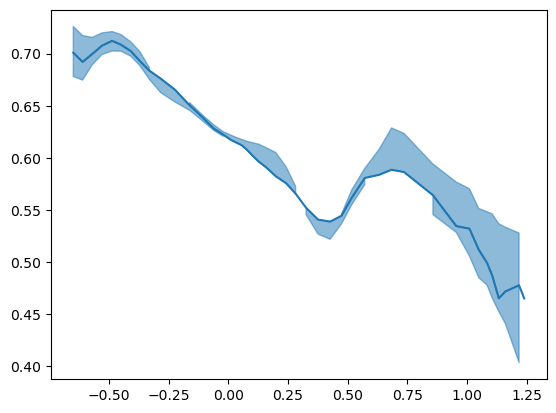

In [337]:
minimos = [min(col) for col in zip(*qs_boot)]
maximos = [max(col) for col in zip(*qs_boot)]
plt.fill_between(mass_bins, qs, maximos, alpha=0.5, color='tab:blue', where = maximos>=qs)
plt.fill_between(mass_bins, minimos, qs, alpha=0.5, color='tab:blue', where = minimos<=qs)

plt.plot(mass_bins, qs)